--- Starting Classification ---

Confusion Matrix:
[[1423    0    0    0]
 [  88    0    0    0]
 [ 110    0    0    0]
 [ 379    0    0    0]]

Classification Report:


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classif

              precision    recall  f1-score   support

   Delivered       0.71      1.00      0.83      1423
     Pending       0.00      0.00      0.00        88
    Returned       0.00      0.00      0.00       110
     Shipped       0.00      0.00      0.00       379

    accuracy                           0.71      2000
   macro avg       0.18      0.25      0.21      2000
weighted avg       0.51      0.71      0.59      2000


--- Starting Clustering ---


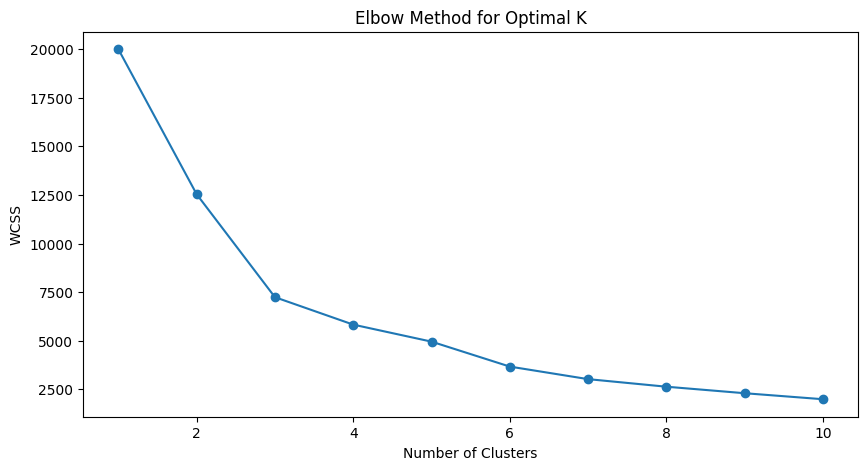

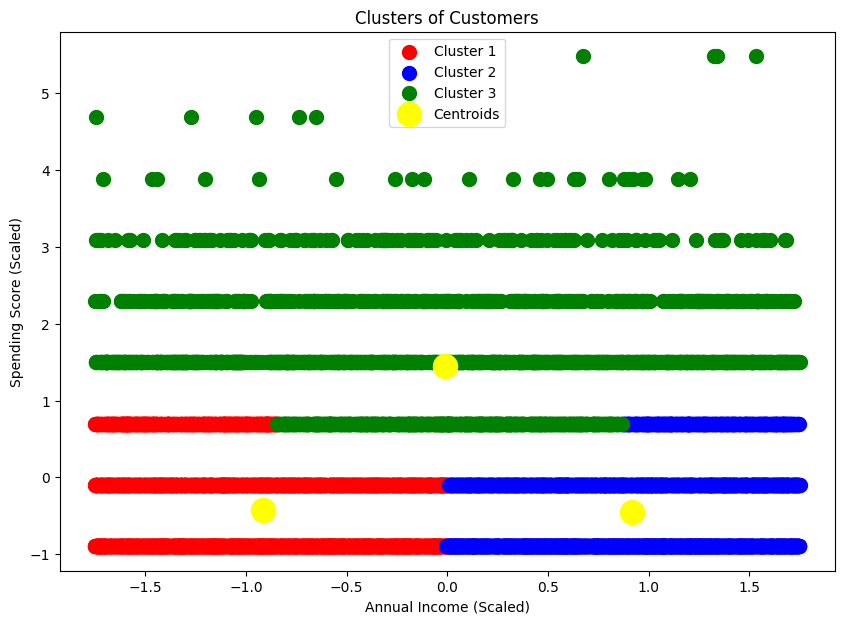


Clustering process completed successfully.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Dataset එක Load කිරීම
# මෙතැනට ඔයාගේ CSV file එකේ නම දෙන්න
df = pd.read_csv('../ecommerce_orders_clean.csv') 

# --- PART 1: CLASSIFICATION (Predicting Customer Segment) ---
print("--- Starting Classification ---")

# --- PART 1: CLASSIFICATION ---

# පවතින Column names අනුව Features (X) තෝරා ගැනීම 
# මෙතැනදී අපි 'price' සහ 'quantity' පාවිච්චි කරමු
X_class = df[['price', 'quantity']] 

# Predict කරන්න ඕනේ 'customer_segment' හෝ 'delivery_status' (ඔයාගේ Assignment එකේ තියෙන විදිහට)
# දැන් අපි predict කරන්නේ delivery status එක
y_class = df['delivery_status']



# Data split කිරීම (Training 80%, Testing 20%)
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# Logistic Regression (Softmax) Model එක Train කිරීම
# multi_class='multinomial' මගින් Softmax regression ක්‍රියාත්මක වේ
classifier = LogisticRegression(solver='lbfgs', max_iter=1000)
classifier.fit(X_train, y_train)

# Predictions ලබා ගැනීම
y_pred = classifier.predict(X_test)

# Evaluation (Confusion Matrix, Precision, Recall, F1)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# --- PART 2: CLUSTERING (K-Means) ---
print("\n--- Starting Clustering ---")

# Clustering සඳහා අවශ්‍ය දත්ත පමණක් තෝරා ගැනීම
X_cluster = df[['price', 'quantity']]

# Data Scaling (K-Means වලදී ඉතා වැදගත් වේ)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow Method මගින් හොඳම K අගය සෙවීම
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Elbow Method Plot එක ඇඳීම
plt.figure(figsize=(10,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# K-Means Model එක Train කිරීම (උදාහරණයක් ලෙස K=3 ගමු)
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Clusters Visualize කිරීම (ප්‍රස්ථාරගත කිරීම)
plt.figure(figsize=(10,7))
plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids')
plt.title('Clusters of Customers')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend()
plt.show()

print("\nClustering process completed successfully.")